# Import libraries

In [269]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr


# Data proceessing

In [270]:
# Load the data
users_df = pd.read_excel("Connection report.xlsx", sheet_name="Final_Users")

In [271]:
# Awareness score calculation
def calculate_awareness_score(row):
    score = 0

    # Awareness question
    if row["Awareness"] == "Si":
        score += 2

    # Precaution question 
    precaution_score = 0
    if pd.notnull(row["Precaution"]):
        answers = [x.strip().lower() for x in str(row["Precaution"]).split("+")]
        if any("vpn" in x for x in answers):
            precaution_score += 2
        if any("cuentas sensibles" in x for x in answers):
            precaution_score += 2
        if any("sitios de confianza" in x for x in answers):
            precaution_score += 1
        if "No" in answers:
            precaution_score = 0
        precaution_score = min(precaution_score, 2)
    score += precaution_score

    # Trust question
    if row["Trust"] == "Si":
        score += 0
    elif row["Trust"] == "A veces, depende del lugar":
        score += 1
    elif row["Trust"] == "No":
        score += 2

    return score

def category(row): 
    if row["awareness_score"] <= 2:
        return "High risk"
    elif row["awareness_score"] <= 4:
        return "Medium risk"
    else:
        return "Low risk"
    
# Apply the function
users_df["awareness_score"] = users_df.apply(calculate_awareness_score, axis=1)
users_df["awareness_category"] = users_df.apply(category, axis=1)



In [272]:
users_df.head()

,MAC Address,IP Address,Connection duration (minutes),Connection duration (seconds),Packets,Bytes,Authenticated time,Location,Date,ID,Edad,Genero,Turista,Purpose,Awareness,Precaution,Trust,awareness_score,awareness_category
0,ba:15:66:83:b8:4d,192.168.3.17,34.403833,2064.23,189745,182402823,17:46:09,Avenida de America,2025-03-10,1,32,H,Si,Trabajo/Estudio,Si,No,Si,2,High risk
1,42:6b:e1:62:7d:e8,192.168.3.58,24.216000,1452.96,107979,90262866,10:24:06,Atocha,2025-03-11,2,32,M,Si,Entretenimiento,Si,No,Si,2,High risk
2,36:a7:e5:4e:1b:c2,192.168.3.102,4.084667,245.08,11815,7205767,10:27:44,Atocha,2025-03-11,3,35,H,Si,Entretenimiento,Si,No,No,4,Medium risk
3,5a:52:5b:4d:3f:c4,192.168.3.137,3.611667,216.70,3947,1287152,10:28:08,Atocha,2025-03-11,4,29,M,No,Trabajo/Estudio,Si,VPN + Evitar iniciar sesion en cuentas sensibles,"A veces, depende del lugar",5,Low risk
4,5a:fd:f2:10:04:35,192.168.3.161,30.164667,1809.88,22513,11392503,10:36:17,Atocha,2025-03-11,5,16,H,Si,Otros,Si,No,"A veces, depende del lugar",3,Medium risk


# Descriptive Statistics

In [273]:
# Summary statistics for numeric variables
users_df.describe()

,Connection duration (minutes),Connection duration (seconds),Packets,Bytes,ID,Edad,awareness_score
count,110.000000,110.000000,110.000000,1.100000e+02,110.000000,110.000000,110.000000
mean,20.366051,1221.963079,35757.554545,2.736812e+07,55.500000,34.809091,3.609091
std,24.102403,1446.144197,54269.707758,4.854221e+07,31.898276,12.669037,1.306971
min,1.106666,66.399948,138.000000,1.299700e+04,1.000000,16.000000,0.000000
25%,5.620395,337.223728,4590.500000,1.611473e+06,28.250000,26.000000,3.000000
50%,12.259826,735.589543,16207.000000,7.900092e+06,55.500000,32.000000,4.000000
75%,24.467154,1468.029263,47180.500000,2.961340e+07,82.750000,39.750000,5.000000
max,139.473876,8368.432535,290860.000000,2.385999e+08,110.000000,60.000000,6.000000


In [274]:
# Count of users by location
users_df.groupby("Location").count()

,MAC Address,IP Address,Connection duration (minutes),Connection duration (seconds),Packets,Bytes,Authenticated time,Date,ID,Edad,Genero,Turista,Purpose,Awareness,Precaution,Trust,awareness_score,awareness_category
Location,,,,,,,,,,,,,,,,,,
Aeropuerto,51,51,51,51,51,51,50,51,51,51,51,51,51,51,51,51,51,51
Atocha,42,42,42,42,42,42,42,42,42,42,42,42,42,42,42,42,42,42
Avenida de America,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Chamartin,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11
Moncloa,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
Starbucks,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2


In [275]:
# Gender distribution
users_df["Genero"].value_counts()

M       55
H       51
Otro     4
Name: Genero, dtype: int64

In [276]:
# Tourist status distribution
users_df["Turista"].value_counts()

Si    91
No    19
Name: Turista, dtype: int64

In [277]:
# Purpose of their connection distribution
users_df["Purpose"].value_counts()

Entretenimiento    40
Trabajo/Estudio    35
Otros              35
Name: Purpose, dtype: int64

In [278]:
# Trust distribution 
users_df["Trust"].value_counts()

A veces, depende del lugar    51
Si                            46
No                            13
Name: Trust, dtype: int64

In [279]:
# Awareness distriribution
users_df["Awareness"].value_counts()

Si    104
No      6
Name: Awareness, dtype: int64

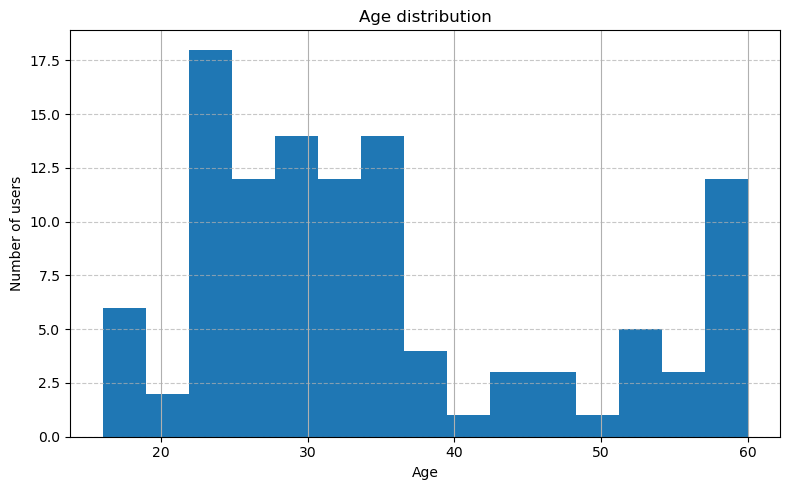

In [280]:
# Age distribution histogram

plt.figure(figsize=(8, 5))
users_df['Edad'].dropna().astype(int).hist(bins=15)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Number of users')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Awareness analysis 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


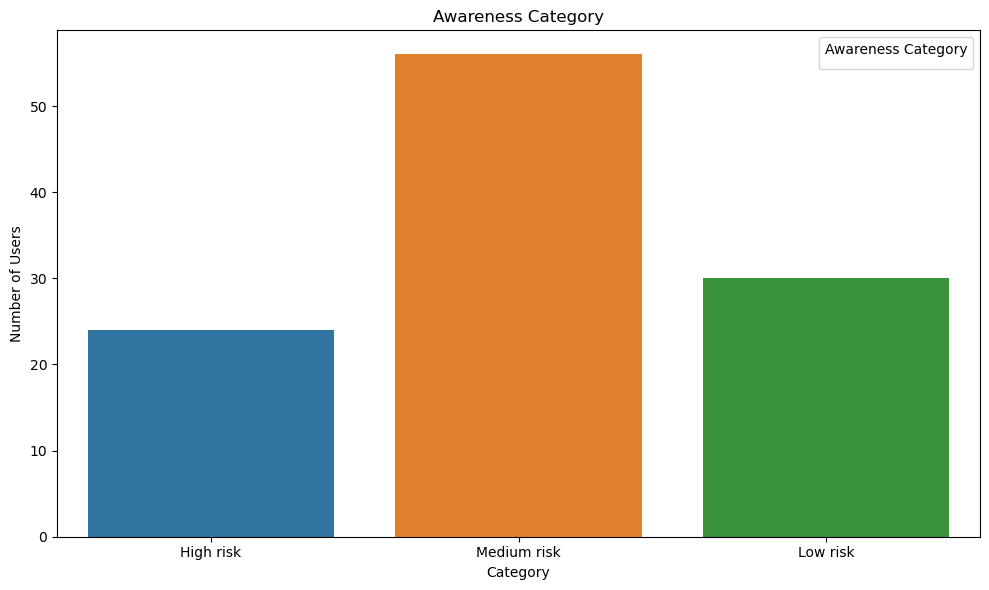

In [282]:
# Awarenss by category distribution

plt.figure(figsize=(10, 6))
sns.countplot(data=users_df, x="awareness_category")
plt.title("Awareness Category")
plt.xlabel("Category")
plt.ylabel("Number of Users")
plt.legend(title="Awareness Category")
plt.tight_layout()
plt.show()

### Awareness and Age

In [283]:
# Pearson correlation between 'Age' and 'awareness_score'

correlation, p_value = pearsonr(users_df['Edad'], users_df['awareness_score'])
print(f"Correlation: {correlation}")
print(f"P-value: {p_value}")

Correlation: 0.025371326190291532
P-value: 0.792474034424974


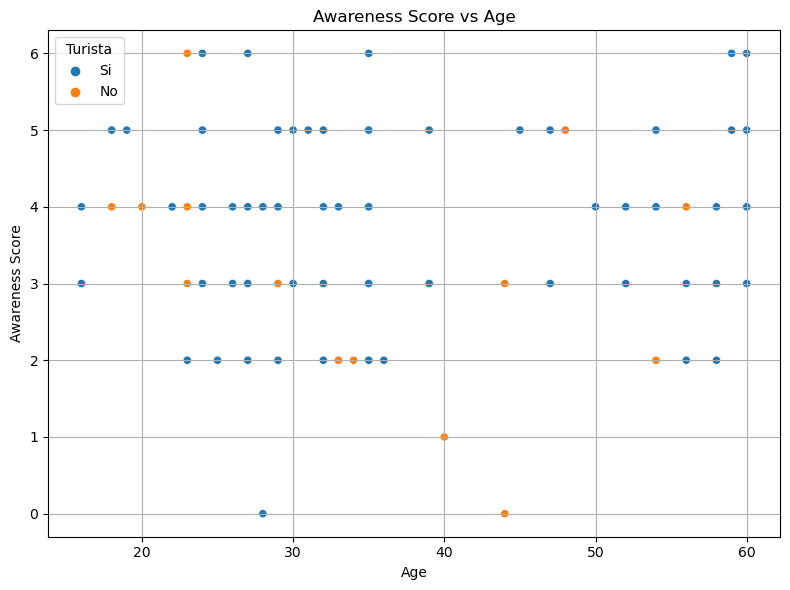

In [284]:
# Scatter plot: Awareness Score vs Age
plt.figure(figsize=(8, 6))
sns.scatterplot(data=users_df, x="Edad", y="awareness_score", hue="Turista")
plt.title("Awareness Score vs Age")
plt.xlabel("Age")
plt.ylabel("Awareness Score")
plt.grid(True)
plt.tight_layout()
plt.show()

### Awareness and Gender

In [285]:
# Chi-squared test between gender and awareness category

contingency = pd.crosstab(users_df['Genero'], users_df['awareness_category'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-squared Statistic:", chi2)
print("P-value:", p)


Chi-squared Statistic: 6.273319327731094
P-value: 0.17964527872407487


### Awareness and Tourist status

In [286]:
# Chi-squared test between tourist status and awareness category

contingency = pd.crosstab(users_df['Turista'], users_df['awareness_category'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-squared Statistic:", chi2)
print("P-value:", p)


Chi-squared Statistic: 0.2772039990085102
P-value: 0.870574448578106


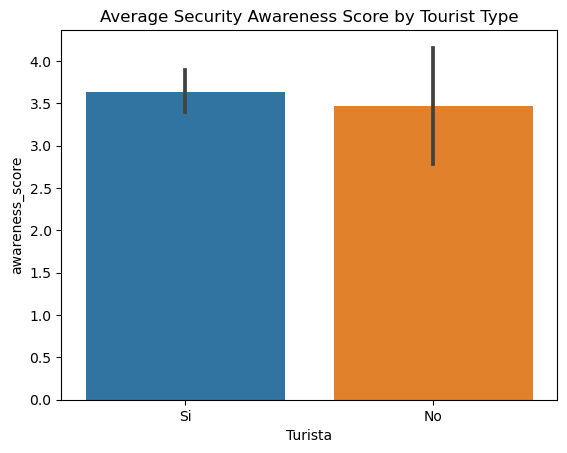

In [287]:
# Bar plot of average security awareness score by tourist type

sns.barplot(x='Turista', y='awareness_score', data=users_df)
plt.title("Average Security Awareness Score by Tourist Type")
plt.show()


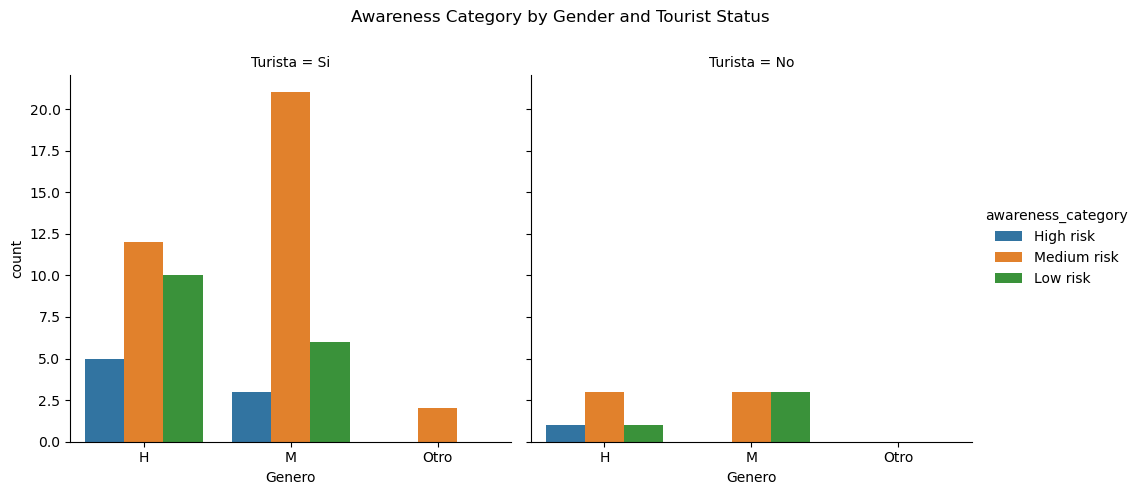

In [124]:
# Bar graph of awareness category by gender and tourist status

g = sns.catplot(
    data=users_df,
    kind="count",
    x="Genero",
    hue="awareness_category",
    col="Turista",
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Awareness Category by Gender and Tourist Status")
plt.show()

### Awareness and Trust

In [289]:
# Chi-squared test between trust and awareness category

contingency = pd.crosstab(users_df['Trust'], users_df['awareness_category'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-squared Statistic:", chi2)
print("P-value:", p)

Chi-squared Statistic: 54.74856352797529
P-value: 3.6679665030653456e-11


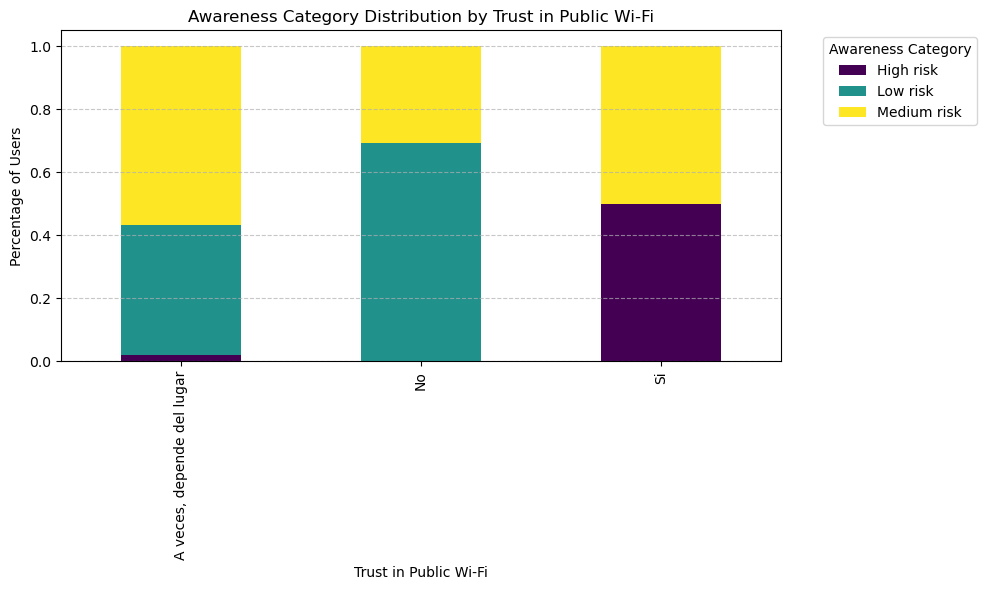

In [290]:
# Plotting the distribution of awareness categories by trust in public Wi-Fi

contingency_percent = contingency.div(contingency.sum(axis=1), axis=0)
contingency_percent.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10,6))
plt.title('Awareness Category Distribution by Trust in Public Wi-Fi')
plt.xlabel('Trust in Public Wi-Fi')
plt.ylabel('Percentage of Users')
plt.legend(title='Awareness Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Awareness and Precautions

In [291]:
# Chi-squared test between precautions and awareness category

contingency = pd.crosstab(users_df['Precaution'], users_df['awareness_category'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-squared Statistic:", chi2)
print("P-value:", p)

Chi-squared Statistic: 96.90352085278558
P-value: 4.178157802280495e-10


In [244]:
# Create a contingency table
contingency = pd.crosstab(df['Category'], df['awareness_category'])

# Perform the Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-squared Statistic:", chi2)
print("P-value:", p)


Chi-squared Statistic: 31.136535151906216
P-value: 0.05341357662254713


# Self-reported behavior vs actual behavior

In [292]:
# Upload the DNS activity data

domains_df = pd.read_excel("dns_activity_final.xlsx")
domains_df.head()

,IP Address,MAC Address,Domain,First Seen,Last Seen,Duration (seconds),Duration (minutes),Location,Date
0,192.168.3.17,ba:15:66:83:b8:4d,googleapis.cn,1.741625e+09,1.741627e+09,1982.38,33.039667,Avenida de America,2025-03-10
1,192.168.3.17,ba:15:66:83:b8:4d,google.com,1.741625e+09,1.741627e+09,1982.78,33.046333,Avenida de America,2025-03-10
2,192.168.3.17,ba:15:66:83:b8:4d,whatsapp.net,1.741625e+09,1.741627e+09,1982.22,33.037000,Avenida de America,2025-03-10
3,192.168.3.17,ba:15:66:83:b8:4d,googleapis.com,1.741625e+09,1.741627e+09,1990.91,33.181833,Avenida de America,2025-03-10
4,192.168.3.17,ba:15:66:83:b8:4d,facebook.com,1.741625e+09,1.741627e+09,2016.29,33.604833,Avenida de America,2025-03-10


In [313]:
# Merging both datasets (user and domains)

df = pd.merge(users_df, domains_df, on = ["IP Address", "MAC Address"], how = "inner")
df.head()

,MAC Address,IP Address,Connection duration (minutes),Connection duration (seconds),Packets,Bytes,Authenticated time,Location_x,Date_x,ID,...,Trust,awareness_score,awareness_category,Domain,First Seen,Last Seen,Duration (seconds),Duration (minutes),Location_y,Date_y
0,ba:15:66:83:b8:4d,192.168.3.17,34.403833,2064.23,189745,182402823,17:46:09,Avenida de America,2025-03-10,1,...,Si,2,High risk,googleapis.cn,1.741625e+09,1.741627e+09,1982.38,33.039667,Avenida de America,2025-03-10
1,ba:15:66:83:b8:4d,192.168.3.17,34.403833,2064.23,189745,182402823,17:46:09,Avenida de America,2025-03-10,1,...,Si,2,High risk,google.com,1.741625e+09,1.741627e+09,1982.78,33.046333,Avenida de America,2025-03-10
2,ba:15:66:83:b8:4d,192.168.3.17,34.403833,2064.23,189745,182402823,17:46:09,Avenida de America,2025-03-10,1,...,Si,2,High risk,whatsapp.net,1.741625e+09,1.741627e+09,1982.22,33.037000,Avenida de America,2025-03-10
3,ba:15:66:83:b8:4d,192.168.3.17,34.403833,2064.23,189745,182402823,17:46:09,Avenida de America,2025-03-10,1,...,Si,2,High risk,googleapis.com,1.741625e+09,1.741627e+09,1990.91,33.181833,Avenida de America,2025-03-10
4,ba:15:66:83:b8:4d,192.168.3.17,34.403833,2064.23,189745,182402823,17:46:09,Avenida de America,2025-03-10,1,...,Si,2,High risk,facebook.com,1.741625e+09,1.741627e+09,2016.29,33.604833,Avenida de America,2025-03-10


In [330]:
# Number of unique domains

df["Domain"].nunique()

576

In [315]:
# Define classification rules

def classify_domain(domain):
    domain = str(domain).lower()
    if any(social in domain for social in ["instagram", "facebook", "whatsapp", "tiktok", "snapchat", "twitter", "pinterest", "linkedin", "wechat", "x"]):
        return "Social Media"
    elif any(ent in domain for ent in ["netflix", "youtube", "hulu", "spotify", "primevideo", "twitch", "music", "itunes"]):
        return "Entertainment"
    elif any(work in domain for work in ["microsoft", "office", "zoom", "slack", "google", "yahoo", "hotmail", "wikipedia", "canva", "mozilla", "grammarly", "github", "adobe", "gmail", "skype", "evernote"]):
        return "Productivity"
    elif any(news in domain for news in ["cnn", "bbc", "nytimes", "reuters", "elpais", "news", "weather", "nyt", "economist"]):
        return "News"
    elif any(shop in domain for shop in ["amazon", "ebay", "aliexpress", "mercadolibre", "shopify", "alibaba"]):
        return "E-commerce"
    elif any(vpn in domain for vpn in ["nordvpn", "surfshark", "expressvpn", "openvpn", "protonvpn", "norton", "vpn", "mcafee"]):
        return "VPN"
    elif any(cloud in domain for cloud in ["dropbox", "drive", "icloud", "oracle", "cloudfare", "cloud", "azure"]):
        return "Cloud Storage"
    elif any(bank in domain for bank in ["bbva", "santander", "paypal", "bank", "banco", "visa", "mastercard"]):
        return "Banking"
    elif any(travel in domain for travel in ["booking", "ticketmaster", "airbnb", "airbus", "yelp", "renfe"]):
        return "Travel/Events"
    elif "local" in domain:
        return "Local/Private"
    else:
        return "Other"

df["Category"] = df["Domain"].apply(classify_domain)

In [316]:
df.head()

,MAC Address,IP Address,Connection duration (minutes),Connection duration (seconds),Packets,Bytes,Authenticated time,Location_x,Date_x,ID,...,awareness_score,awareness_category,Domain,First Seen,Last Seen,Duration (seconds),Duration (minutes),Location_y,Date_y,Category
0,ba:15:66:83:b8:4d,192.168.3.17,34.403833,2064.23,189745,182402823,17:46:09,Avenida de America,2025-03-10,1,...,2,High risk,googleapis.cn,1.741625e+09,1.741627e+09,1982.38,33.039667,Avenida de America,2025-03-10,Productivity
1,ba:15:66:83:b8:4d,192.168.3.17,34.403833,2064.23,189745,182402823,17:46:09,Avenida de America,2025-03-10,1,...,2,High risk,google.com,1.741625e+09,1.741627e+09,1982.78,33.046333,Avenida de America,2025-03-10,Productivity
2,ba:15:66:83:b8:4d,192.168.3.17,34.403833,2064.23,189745,182402823,17:46:09,Avenida de America,2025-03-10,1,...,2,High risk,whatsapp.net,1.741625e+09,1.741627e+09,1982.22,33.037000,Avenida de America,2025-03-10,Social Media
3,ba:15:66:83:b8:4d,192.168.3.17,34.403833,2064.23,189745,182402823,17:46:09,Avenida de America,2025-03-10,1,...,2,High risk,googleapis.com,1.741625e+09,1.741627e+09,1990.91,33.181833,Avenida de America,2025-03-10,Productivity
4,ba:15:66:83:b8:4d,192.168.3.17,34.403833,2064.23,189745,182402823,17:46:09,Avenida de America,2025-03-10,1,...,2,High risk,facebook.com,1.741625e+09,1.741627e+09,2016.29,33.604833,Avenida de America,2025-03-10,Social Media


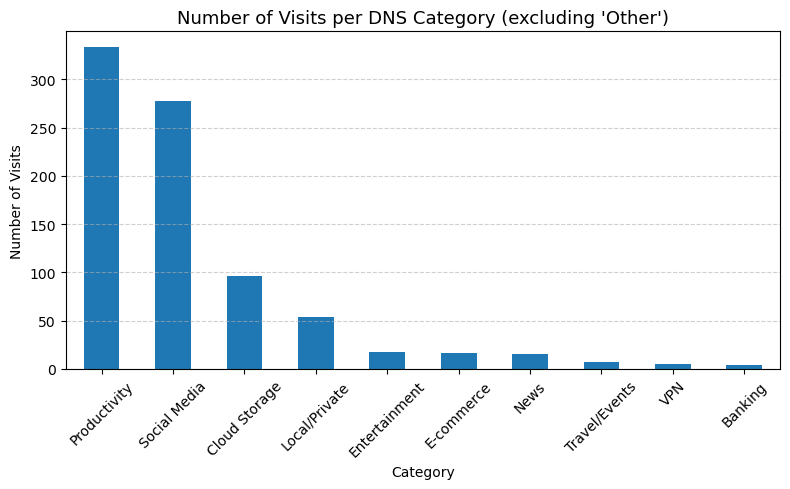

In [331]:
# Count categories excluding 'Other'
category_counts = df["Category"].value_counts()
category_counts = category_counts[category_counts.index != "Other"]

plt.figure(figsize=(8, 5))
category_counts.plot(kind='bar')
plt.title("Number of Visits per DNS Category (excluding 'Other')", fontsize=13)
plt.xlabel("Category")
plt.ylabel("Number of Visits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Check if the stated purpose matches with their actual activity

In [332]:
category_per_user = df.groupby(["MAC Address", "IP Address", "Category"]).size().reset_index(name="Count")
category_per_user = category_per_user[category_per_user["Category"] != "Other"]

most_visited = category_per_user.sort_values(["MAC Address", "IP Address", "Count"], ascending=False).drop_duplicates(subset=["MAC Address", "IP Address"])
final = pd.merge(most_visited, users_df, on=["MAC Address", "IP Address"])

final = final[["MAC Address", "IP Address", "Category", "Purpose"]]

In [319]:
def match_purpose_category(row):
    if row["Purpose"] == "Trabajo/Estudio" and row["Category"] == "Productivity":
        return 1
    elif row["Purpose"] == "Entretenimiento" and (row["Category"] == "Social Media" or row["Category"] == "Entertainment"):
        return 1
    elif row["Purpose"] == "Otros" and (row["Category"] != "Social Media" and row["Category"] != "Productivity" and row["Category"] != "Entertainment"):
        return 1
    else:
        return 0
    
final["Match"] = final.apply(match_purpose_category, axis=1)
final

,MAC Address,IP Address,Category,Purpose,Match
0,fe:ae:10:ea:78:f2,192.168.3.73,Social Media,Trabajo/Estudio,0
1,f6:8f:78:1e:ee:4a,192.168.3.149,Social Media,Otros,0
2,f6:5e:e4:f5:69:43,192.168.3.193,Productivity,Entretenimiento,0
3,f2:d0:b0:b0:da:c5,192.168.3.80,Productivity,Trabajo/Estudio,1
4,ee:3e:f7:8d:48:d3,192.168.3.8,Social Media,Trabajo/Estudio,0
...,...,...,...,...,...
70,26:75:d7:1e:c2:ef,192.168.3.23,Productivity,Otros,0
71,1e:66:3f:36:ea:36,192.168.3.35,Social Media,Trabajo/Estudio,0
72,14:75:5b:42:a2:43,192.168.3.193,Productivity,Trabajo/Estudio,1
73,0a:fd:58:3f:be:7c,192.168.3.199,Productivity,Trabajo/Estudio,1


In [320]:
# % of users for which the purpose matches what they say they are doing
final["Match"].sum() / len(final) * 100

32.0

### VPN check

In [321]:
vpn_domains = [
    "norton.com", "surfshark.com", "expressvpn.com", "nordvpn.com",
    "cyberghostvpn.com", "protonvpn.com", "privateinternetaccess.com",
    "windscribe.com", "tunnelbear.com", "avira-vpn.com", "mcafee.com"
]

# Filter users that selected the "VPN" option 
vpn_claimed = df[df["Precaution"].str.contains("VPN", na=False)]

# Check if the domain is in the list of VPN domains
vpn_claimed["VPN_Used"] = vpn_claimed["Domain"].isin(vpn_domains).astype(int)

/var/folders/l5/f0f0dckn357fbg050cyg7vh00000gn/T/ipykernel_70760/2840227787.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vpn_claimed["VPN_Used"] = vpn_claimed["Domain"].isin(vpn_domains).astype(int)


In [322]:
vpn_usage_summary = vpn_claimed.groupby(["IP Address", "MAC Address"]).agg(
    Used_VPN=("VPN_Used", "sum")
).reset_index()

vpn_usage_summary

,IP Address,MAC Address,Used_VPN
0,192.168.3.11,ae:c5:1a:19:3e:37,0
1,192.168.3.137,5a:52:5b:4d:3f:c4,0
2,192.168.3.193,14:75:5b:42:a2:43,0
3,192.168.3.193,de:76:77:58:59:9d,2
4,192.168.3.193,f6:5e:e4:f5:69:43,0
5,192.168.3.3,c2:22:88:87:61:f5,0
6,192.168.3.88,a2:39:15:2f:4e:74,0


In [323]:
# Based on the users that claimed to use VPN, how many of them actually used it?
vpn_usage_summary[vpn_usage_summary.Used_VPN != 0].shape[0] / vpn_usage_summary.shape[0] 

0.14285714285714285

### Online content engagement analysis

In [325]:
unique_user_category = df[['MAC Address', 'IP Address', 'awareness_category', 'awareness_score', 'Category']].drop_duplicates()

# Count unique categories per user
category_counts = unique_user_category.groupby(['MAC Address', 'IP Address', 'awareness_category', 'awareness_score'])['Category'].nunique().reset_index()

# Pearson correlation between 'Category count' and 'awareness_score'

correlation, p_value = pearsonr(category_counts['awareness_score'], category_counts['Category'])
print(f"Correlation: {correlation}")
print(f"P-value: {p_value}")

Correlation: 0.13394767728893253
P-value: 0.2519155394268176


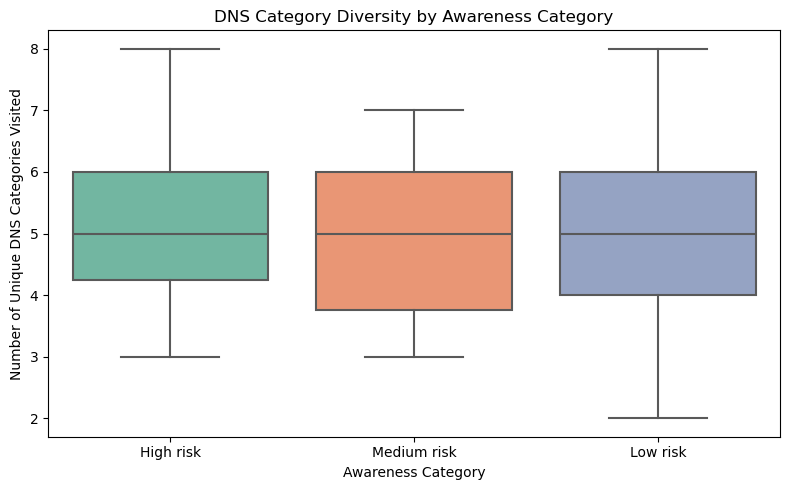

In [326]:
# Boxplot 
plt.figure(figsize=(8, 5))
sns.boxplot(data=category_counts, x='awareness_category', y='Category', palette='Set2')
plt.title('DNS Category Diversity by Awareness Category')
plt.xlabel('Awareness Category')
plt.ylabel('Number of Unique DNS Categories Visited')
plt.tight_layout()
plt.show()

### Deep dive into the "Banking" category

In [337]:
df[df["Category"] == "Banking"][["IP Address", "Precaution", "awareness_category", "Domain"]]

,IP Address,Precaution,awareness_category,Domain
429,192.168.3.160,Evitar iniciar sesion en cuentas sensibles,Low risk,bancociudad.com.ar
1272,192.168.3.138,No,High risk,bancosantander.es
1617,192.168.3.193,VPN,Medium risk,mastercard.com
2046,192.168.3.151,No,High risk,novobanco.pt


# Behavioral patterns by location

### Location vs Awareness 

In [341]:
# Chi-square test between Location and Awareness Category

contingency = pd.crosstab(users_df['Location'], users_df['awareness_category'])
chi2, p, _, _ = chi2_contingency(contingency)
print("p-value:", p)

p-value: 0.3499900097505964


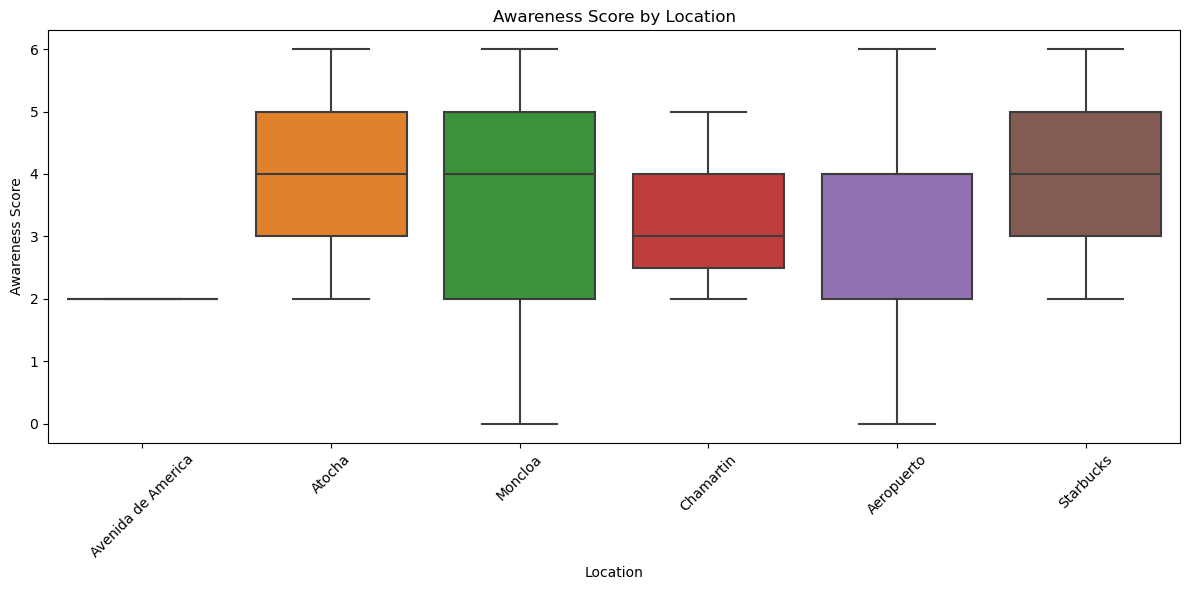

In [342]:
# Boxplot of awareness score by location

plt.figure(figsize=(12, 6))
sns.boxplot(data=users_df, x="Location", y="awareness_score")
plt.xticks(rotation=45)
plt.title("Awareness Score by Location")
plt.xlabel("Location")
plt.ylabel("Awareness Score")
plt.tight_layout()
plt.show()

### Location vs Trust 

In [343]:
# Chi-square test between Location and Trust

contingency = pd.crosstab(users_df['Location'], users_df['Trust'])
chi2, p, _, _ = chi2_contingency(contingency)
print("p-value:", p)

p-value: 0.11846363160893657


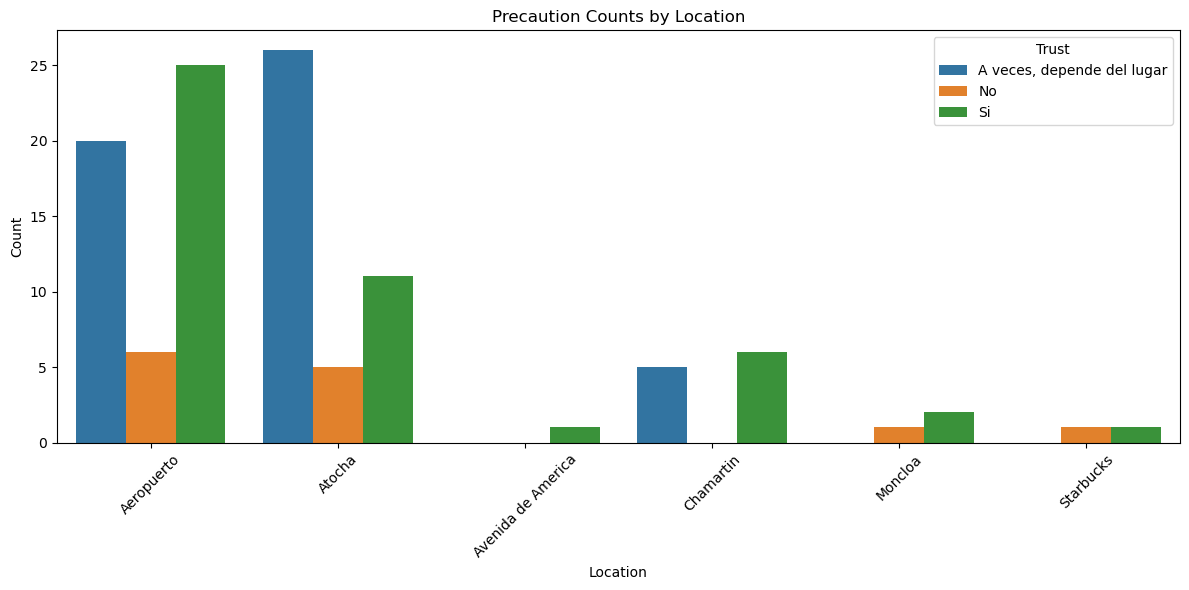

In [348]:
counts = users_df.groupby(['Location', 'Trust']).size().reset_index(name='Count')

plt.figure(figsize=(12, 6))
sns.barplot(data=counts, x='Location', y='Count', hue='Trust')
plt.title("Precaution Counts by Location")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Location vs Precautions taken

In [344]:
# Chi-square test between Location and Precaution

contingency = pd.crosstab(users_df['Location'], users_df['Precaution'])
chi2, p, _, _ = chi2_contingency(contingency)
print("p-value:", p)

p-value: 0.0008367180068166949


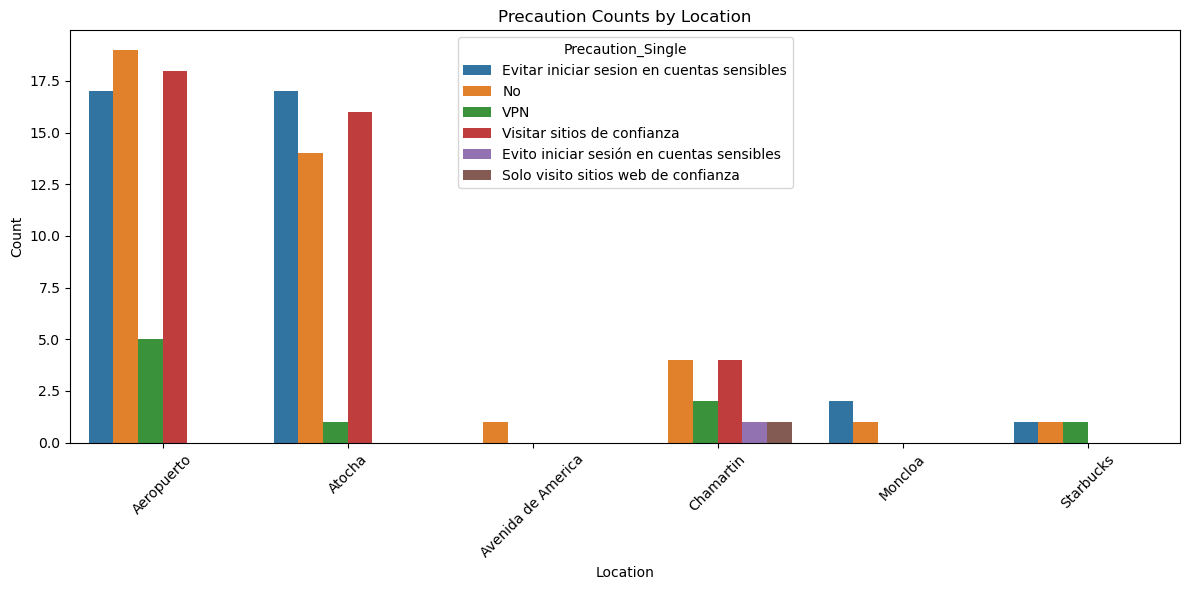

In [349]:
pre_df = users_df.copy()

# Split multiple precautions into lists 
pre_df["Precaution_Split"] = pre_df["Precaution"].str.split(r"\s*\+\s*")

# Explode the list into separate rows so that each row has only one precaution
pre_df = pre_df.explode("Precaution_Split").rename(columns={"Precaution_Split": "Precaution_Single"})

# Strip whitespace and unify formatting
pre_df["Precaution_Single"] = pre_df["Precaution_Single"].str.strip()

precaution_counts = pre_df.groupby(['Location', 'Precaution_Single']).size().reset_index(name='Count')

plt.figure(figsize=(12, 6))
sns.barplot(data=precaution_counts, x='Location', y='Count', hue='Precaution_Single')
plt.title("Precaution Counts by Location")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

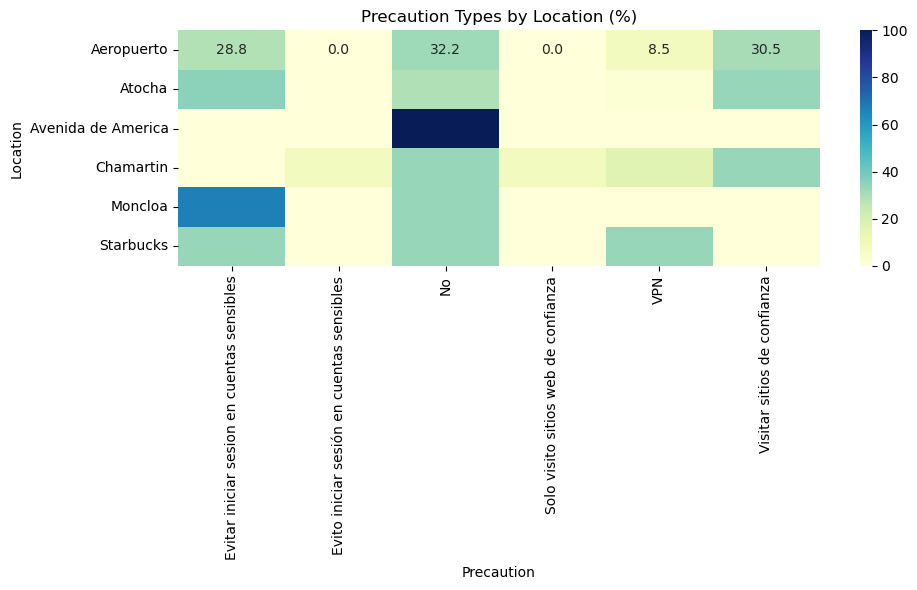

In [350]:
# Cross-tabulation
contingency = pd.crosstab(pre_df['Location'], pre_df['Precaution_Single'], normalize='index') * 100

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(contingency, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title("Precaution Types by Location (%)")
plt.ylabel("Location")
plt.xlabel("Precaution")
plt.tight_layout()
plt.show()

# Additional findings from the analysis

### Deep dive into the "Work/Study" purpose

In [345]:
# Filter the data to only include users who connect for working or studying purposes

working = users_df[(users_df.Purpose == "Trabajo/Estudio") & (users_df.Edad >=23)]
working.awareness_category.value_counts()

Medium risk    13
Low risk       10
High risk       8
Name: awareness_category, dtype: int64

### Trust vs Connection Duration

In [351]:
# Average connection duration by Trust

users_df.groupby("Trust").mean("Connection duration (minutes)")

,Connection duration (minutes),Connection duration (seconds),Packets,Bytes,ID,Edad,awareness_score
Trust,,,,,,,
"A veces, depende del lugar",21.310007,1278.600412,37792.960784,2.886357e+07,46.843137,35.215686,4.039216
No,14.569367,874.162001,24443.615385,1.548855e+07,56.538462,32.153846,5.230769
Si,20.957685,1257.461123,36698.326087,2.906740e+07,64.804348,35.108696,2.673913


### Contradictions 

In [352]:
# Contradiction between Trust and Precaution as users who don't trust that public networks are secure should take more precautions

users_df[(users_df.Trust == "No") & (users_df.Precaution == "No")]

,MAC Address,IP Address,Connection duration (minutes),Connection duration (seconds),Packets,Bytes,Authenticated time,Location,Date,ID,Edad,Genero,Turista,Purpose,Awareness,Precaution,Trust,awareness_score,awareness_category
2,36:a7:e5:4e:1b:c2,192.168.3.102,4.084667,245.080000,11815,7205767,10:27:44,Atocha,2025-03-11,3,35,H,Si,Entretenimiento,Si,No,No,4,Medium risk
41,aa:fc:df:72:45:a9,192.168.3.200,3.329297,199.757808,2089,539063,09:32:36,Aeropuerto,2025-03-28,42,16,M,Si,Entretenimiento,Si,No,No,4,Medium risk
